In [2]:
import numpy as np
import matplotlib.pyplot as plt
sourceDir = "/home/philipp/NATriuM/NATriuM/src/examples/step-grid-in/mesh/varyRefinement"

In [3]:
filename = sourceDir + "/naca0012_res100.txt"
x = []
y = []
with open(filename, "r") as file:
  string = file.read()
  string = string.splitlines()[1:-1]
  for line in string:
    if line not in ['', ' ']:
      line = line.split(' ')
      line = [l for l in line if l != '']
      x.append(float(line[0]))
      y.append(float(line[1]))
xCos = np.array(x)
yCos = np.array(y)

In [4]:
filename = sourceDir + "/naca0012_res100_linear.txt"
x = []
y = []
with open(filename, "r") as file:
  string = file.read()
  string = string.splitlines()[1:-1]
  for line in string:
    if line not in ['', ' ']:
      line = line.split(' ')
      line = [l for l in line if l != '']
      x.append(float(line[0]))
      y.append(float(line[1]))
xLin = np.array(x)
yLin = np.array(y)

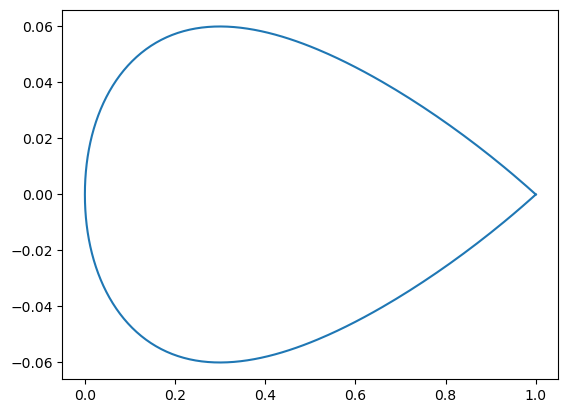

(2, 199)


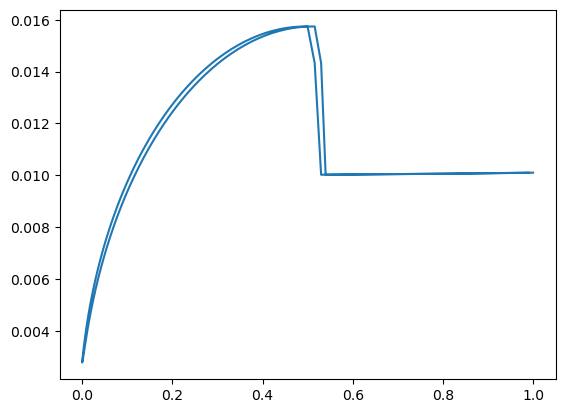

In [6]:
ol = .52  # overlap
xCombined = np.concat((xLin[(xLin>ol)*(yLin>=0)],xCos[xCos<ol],xLin[(xLin>ol)*(yLin<0)],[1]))
yCombined = np.concat((yLin[(xLin>ol)*(yLin>=0)],yCos[xCos<ol],yLin[(xLin>ol)*(yLin<0)],[0]))
coords = np.stack((xCombined,yCombined))
# coords = np.sort(coords,axis=0)
plt.plot(coords[0,:],coords[1,:])
plt.show()
print(coords.shape)

dx = np.sqrt(np.pow(xCombined[1:] - xCombined[:-1],2) + np.pow(yCombined[1:] - yCombined[:-1],2))
plt.plot(xCombined[:-1],dx)
plt.show()

In [7]:
np.savetxt(sourceDir + "/naca0012_res100_combined.txt", coords.T, header="NACA 0012 Airfoil M=0.0% P=0.0% T=12.0%")